#Report di Progetto
Asset Allocation ML – driven con Walk – Forward Analysis

Gruppo di lavoro: Giada Testa, Sebastian Castro e Leonardo Mezzoprete


In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import xgboost as xgb
from datetime import datetime
from scipy.stats import spearmanr # Metrica per valutare la qualità del ranking

#BLOCCO 2: "DATASET:CONFIGURAZIONE E ACQUISIZIONE DATI"



In [2]:
# 2. CONFIGURAZIONE E ACQUISIZIONE DATI (Paniere "Long History")
'''
Definiamo il paniere "Tech & Innovation" ottimizzato per avere uno storico di almeno 15 anni.
Abbiamo sostituito gli asset troppo giovani (BITO, ARKK) con equivalenti storici (XBI, FDN).
'''

# QQQ: Nasdaq 100 (Big Tech) -> Benchmark Tecnologico
# SOXX: Semiconduttori (Hardware) -> Sostituisce SMH per maggior storico (dal 2001)
# FDN:  Internet Index (Growth/Web) -> Sostituisce ARKK come proxy Innovation (dal 2006)
# XBI:  Biotech (High Volatility/Innovation) -> Sostituisce BITO come asset ad alto rischio/rendimento (dal 2006)
# BIL:  T-Bills 1-3 Mesi (Cash/Risk-off) -> Asset Rifugio

TICKERS = ['QQQ', 'SOXX', 'FDN', 'XBI', 'BIL']

# Impostiamo la data di inizio per avere almeno 15 anni di storico.
# Partendo dal 2010, abbiamo circa 15-16 anni di dati settimanali.
START_DATE = '2010-01-01'
END_DATE = datetime.today().strftime('%Y-%m-%d')

print(f"1. Scaricamento dati per il paniere {TICKERS}...")
# Scarichiamo i prezzi di chiusura aggiustati (auto_adjust=True gestisce dividendi e split)
raw_data = yf.download(TICKERS, start=START_DATE, end=END_DATE, auto_adjust=True)['Close']

# Controllo integrità dati
if raw_data.isnull().values.any():
    print("   Avviso: Ci sono dati mancanti, pertanto ...")
    raw_data = raw_data.ffill().dropna()

# RESAMPLING SETTIMANALE
# Convertiamo i dati giornalieri in settimanali (chiusura del Venerdì).
# Questo riduce il "rumore" di mercato e stabilizza i segnali di trend, dei dati giornalieri sarebbero troppo caotici.
data_weekly = raw_data.resample('W-FRI').last().dropna()

print(f"   Dati pronti dal {data_weekly.index[0].date()} al {data_weekly.index[-1].date()}")
print(f"   Totale settimane disponibili: {len(data_weekly)}")

'''

# Picola verifica preliminare
print("\nPrime 5 righe del dataset settimanale:")
print(data_weekly.head())

'''

1. Scaricamento dati per il paniere ['QQQ', 'SOXX', 'FDN', 'XBI', 'BIL']...


[*********************100%***********************]  5 of 5 completed

   Dati pronti dal 2010-01-08 al 2026-01-30
   Totale settimane disponibili: 839


'\n\n# Picola verifica preliminare\nprint("\nPrime 5 righe del dataset settimanale:")\nprint(data_weekly.head())\n\n'

# BLOCCO 3: "FEATURE ENGINEERING"

Per aiutare il modello a fare previsioni più precise e a non farsi ingannare dai movimenti casuali del mercato ("rumore"), abbiamo aggiunto due nuovi indicatori fondamentali.

L'idea è dare al modello due informazioni che prima gli mancavano:

### 1. Bollinger Bands %B
Questo indicatore serve a capire se il prezzo è salito o sceso troppo velocemente rispetto al solito; l'obiettivo è capire se il prezzo è "esagerato".
* **Come funziona:** Se il valore è alto (vicino a 1 o superiore), significa che l'asset è "caro" e potrebbe scendere presto. Al contrario se è basso, potrebbe essere un buon momento per comprare.
* **Perché l'abbiamo messo:** Serve a impedire al modello di comprare sui massimi assoluti, cosi da ridurre il rischio di perdite immediate.

### 2. Distanza dalla Media a 50 settimane
Questo indicatore misura quanto il prezzo è lontano dalla sua media dell'ultimo anno (perciò abbiamo usato 50 settimane); grazie a questo indicatore possiamo capire se la "direzione" è verso l'alto o verso il basso.
* **Come funziona:**
    * Se il prezzo è **sopra** la media, il trend generale è positivo (Toro); significa che vi è ottimismo. Pertanto se il prezzo scendesse un po' il modello riuscirebbe a capire che si tratta solamente di una pausa istantanea e procede a comprare.
    * Se il prezzo è **sotto** la media, il trend generale è negativo (Orso); vi è pessimismo. Se il modello notasse un segnale di acquisto, ci pensa due volte prima di comprare; detto in maniera diversa, capisce che "nuotare controcorrente" (comprare mentre tutto crolla) è pericoloso. Perciò probabilmente sceglierà di stare fuori o comprare asset sicuri (come BIL).
* **Perché l'abbiamo messo:** Ora il modello ha una "bussola" per capire se sta navigando in acque calme o in tempesta, evitando di investire contro la corrente principale. Senza questa "bussola", se il modello vedesse un prezzo scendere del 5% e potrebbe pensare che quell'asset sia economico (e si precipiterebbe a comprarlo). Ma se quel calo del 5% fa parte di un crollo totale del mercato (come nel 2008 o 2022), comprare risulterebbe disastroso.
Riassumendo, grazie a questo indicatore, il modello smette di inseguire i piccoli movimenti giornalieri (le onde) e inizia a guardare la direzione generale del mare (la marea), evitando di comprare azioni quando il mercato sta crollando nel lungo periodo.



In [3]:
# 3. FEATURE ENGINEERING

# A. FUNZIONI DI SUPPORTO

def calculate_rsi(series, period=14):
    """
    Calcola l'RSI (Relative Strength Index).
    Indica se l'asset è ipercomprato (>70) o ipervenduto (<30).
    """
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

def calculate_macd(series, slow=26, fast=12, signal=9):
    """
    Calcola l'istogramma MACD.
    Utile per identificare cambiamenti nel momentum.
    """
    exp1 = series.ewm(span=fast, adjust=False).mean()
    exp2 = series.ewm(span=slow, adjust=False).mean()
    macd = exp1 - exp2
    signal_line = macd.ewm(span=signal, adjust=False).mean()
    return macd - signal_line

# FUNZIONE: Bollinger Bands %B
def calculate_bollinger_b(series, window=20, num_std=2):
    """
    Calcola la posizione del prezzo rispetto alle Bande di Bollinger (%B).
    > 1: Prezzo sopra la banda superiore (Eccesso rialzista).
    < 0: Prezzo sotto la banda inferiore (Eccesso ribassista).
    """
    sma = series.rolling(window).mean()
    std = series.rolling(window).std()
    upper_band = sma + (std * num_std)
    lower_band = sma - (std * num_std)
    percent_b = (series - lower_band) / (upper_band - lower_band)
    return percent_b


# B. CICLO DI CREAZIONE DATASET
dfs_list = []

for ticker in TICKERS:
    # Creiamo un dataframe temporaneo per ogni singolo ticker
    temp = pd.DataFrame(index=data_weekly.index)
    price = data_weekly[ticker]

    # Feature del Momentum (Spinta)
    temp['ret_1w'] = np.log(price / price.shift(1))
    temp['ret_4w'] = np.log(price / price.shift(4))

    # Feature della Volatilità (Rischio)
    temp['vol_4w'] = temp['ret_1w'].rolling(4).std()
    temp['vol_12w'] = temp['ret_1w'].rolling(12).std()

    # Feature di Mean Reversion (Statistica)
    sma_20 = price.rolling(20).mean()
    std_20 = price.rolling(20).std()
    temp['zscore_20'] = (price - sma_20) / std_20

    temp['rsi'] = calculate_rsi(price)
    temp['macd_hist'] = calculate_macd(price)

    # Bollinger Band %B
    temp['bb_percent_b'] = calculate_bollinger_b(price)

    # Distanza dalla SMA 50 (Trend di Lungo Termine, cioè la "Bussola")
    sma_50 = price.rolling(50).mean()
    temp['dist_sma50'] = (price - sma_50) / sma_50

    # TARGET (etichetta da prevedere)
    # Lo shift è -1 perché vogliamo prevedere il rendimento della settimana successiva
    temp['target_return'] = temp['ret_1w'].shift(-1)
    temp['Ticker'] = ticker

    dfs_list.append(temp)


# C. PULIZIA E FORMATTAZIONE
# Uniamo tutto in un unico DataFrame
df_full = pd.concat(dfs_list).dropna()

# Ordiniamo per data (serve per XGBRanker)
df_full = df_full.sort_index()

# Creazione Rank Target (Classifica 0-4 per ogni settimana)
'''
Passo 1: Prende ogni singola settimana (groupby(level='Date')).
Passo 2: Guarda i rendimenti dei 5 asset.
Passo 3: Li mette in fila dal peggiore al migliore (rank(ascending=True)).
Passo 4: Assegna un'etichetta da 0 a 4.

Etichette:
0 = L'asset peggiore della settimana (es. quello che ha perso di più).
1 = Il penultimo.
2 = Quello medio.
3 = Il secondo migliore.
4 = Il vincitore della settimana (quello che ha guadagnato di più o perso di meno).

Si cerca di capire quale tra gli asset sia il migliore.
'''
df_full['target_rank'] = df_full.groupby(level='Date')['target_return'].rank(ascending=True) - 1

# Lista finale delle colonne input
feature_cols = [
    'ret_1w', 'ret_4w',           # Momentum
    'vol_4w', 'vol_12w',          # Volatilità
    'zscore_20', 'bb_percent_b',  # Mean Reversion
    'rsi', 'macd_hist',           # Technicals
    'dist_sma50'                  # Trend Lungo Termine
]

print(f"Feature Engineering completato.")
print(f"Dimensioni Dataset: {df_full.shape}")
print(f"Features utilizzate ({len(feature_cols)}): {feature_cols}")

Feature Engineering completato.
Dimensioni Dataset: (3945, 12)
Features utilizzate (9): ['ret_1w', 'ret_4w', 'vol_4w', 'vol_12w', 'zscore_20', 'bb_percent_b', 'rsi', 'macd_hist', 'dist_sma50']


# SPIEGAZIONE BLOCCO 3: "FEATURE ENGINEERING"

In questa fase cruciale, il nostro obiettivo è trasformare i dati grezzi dei prezzi in informazioni significative. Un modello di Machine Learning non "vede" i grafici come un essere umano; ha bisogno di input numerici (le **Features**) che descrivano matematicamente lo stato del mercato.

Abbiamo progettato un set di indicatori che agiscono come i "sensori" del modello, divisi in quattro categorie logiche:

### A. I "Sensori" del Modello (cioè gli input)

**1. Momentum e Trend**
* **Indicatori:** `ret_1w` (1 settimana), `ret_4w` (1 mese) e `dist_sma50` (Trend 1 Anno).
* **La Logica:** Ci basiamo sul principio finanziario che "la forza genera forza".
    * I rendimenti passati (`ret`) dicono al modello quanto velocemente l'asset sta correndo.
    * La distanza dalla media a 50 settimane (`dist_sma50`) agisce come una **bussola di lungo periodo**: se il prezzo è sopra questa media, siamo in un mercato "Toro" (rialzista) e il modello sarà più propenso a comprare; se è sotto, siamo in un mercato "Orso" (ribassista) e il modello diventerà difensivo.

**2. Mean Reversion ed Eccessi (cioè l'effetto elastico)**
* **Indicatori:** `bb_percent_b` (Bollinger Bands) e `zscore_20`.
* **La Logica:** I mercati non si muovono in linea retta, ma oscillano. Immaginiamo il prezzo come un elastico:
    * Se il prezzo strappa violentemente verso l'alto (toccando la Banda di Bollinger superiore o avendo uno Z-Score alto), l'elastico è teso ed è probabile un ritracciamento (**Ipercomprato**).
    * Questi indicatori servono a frenare il modello dal "comprare sui massimi", un errore tipico dei trader neofiti.

**3. Volatilità e Rischio**
* **Indicatori:** `vol_4w` e `vol_12w`.
* **La Logica:** Misuriamo quanto il mercato è nervoso. Durante i crolli o le crisi, la volatilità esplode. Fornendo questo dato, permettiamo all'algoritmo di imparare che, storicamente, alta volatilità spesso precede perdite sugli asset rischiosi, suggerendo di spostarsi su asset sicuri (come BIL).

**4. Analisi Tecnica Classica**
* **Indicatori:** `RSI` e `MACD`.
* Sono gli strumenti standard del trading algoritmico che sintetizzano velocità ed accellerazione del prezzo, fornendo segnali di conferma aggiuntivi.

---

### B. Il Target: Cosa deve imparare il modello? (Output)

Per addestrare l'AI, dobbiamo fornirle la "risposta corretta" da prevedere. Qui abbiamo fatto due operazioni fondamentali:

1.  **Spostamento Temporale (`shift(-1)`):** Poiché vogliamo fare previsioni, usiamo i dati di *oggi* per prevedere il rendimento della settimana *prossima*.
2.  **Da Regressione a Ranking (La "Gara di Cavalli"):**
    * Invece di chiedere al modello *"Quanto guadagnerà esattamente Apple?"* (difficilissimo), gli chiediamo: *"Tra Apple, Nvidia e Bitcoin, chi arriverà primo venerdì prossimo?"*.
    * Abbiamo trasformato i rendimenti futuri in una **Classifica (Rank 0-4)**. Questo approccio è molto più robusto perché elimina il rumore del mercato generale: se tutto il mercato crolla, ci basta sapere quale asset crollerà *di meno* per salvare il nostro capitale.

 **Nota Tecnica:** Per rendere possibile questo confronto, i dati sono stati strutturati in formato "Long" e ordinati temporalmente, permettendo all'algoritmo XGBoost Ranker di confrontare gli asset tra loro settimana per settimana.

In [4]:
# 4. MODELLI ML

# Simuliamo il trading settimana per settimana.
# Training Window: Usiamo 52 settimane (1 anno) di storia passata per addestrare il modello.
# Rebalance Step: Ogni settimana ricalcoliamo tutto e prendiamo nuove decisioni.
TRAIN_WINDOW = 52
REBALANCE_STEP = 1

# Liste per salvare i risultati man mano che avanziamo nel tempo
predictions_reg = []  # Per XGBRegressor
predictions_rank = [] # Per XGBRanker
metrics_spearman = {'Regressor': [], 'Ranker': []} # Per monitorare la qualità della previsione

# Otteniamo la lista di tutte le date uniche (Venerdì)
dates = sorted(df_full.index.unique())

# CICLO TEMPORALE
# Partiamo dalla settimana 52 e avanziamo fino alla fine
for i in range(TRAIN_WINDOW, len(dates) - 1, REBALANCE_STEP):

    # 1. Definiamo le finestre temporali
    train_start = dates[i - TRAIN_WINDOW] # Inizio Training (es. 1 anno fa)
    train_end = dates[i] # Fine Training (oggi)
    test_date = dates[i + 1] # Settimana di Test (prossima settimana, su cui investiamo)

    # 2. Estrazione Dati Training (Rolling Window)
    train_mask = (df_full.index >= train_start) & (df_full.index <= train_end)
    train_data = df_full.loc[train_mask].sort_index() # Sort necessario per il Ranker

    X_train = train_data[feature_cols]
    y_train_rank = train_data['target_rank'] # Target discreto (0-4)
    y_train_reg = train_data['target_rank'] # Usiamo lo stesso target per confronto equo

    # Calcolo gruppi per XGBRanker: dice al modello quanti asset ci sono per ogni data
    # (es: [5, 5, 5...] significa "confronta a gruppi di 5")
    train_groups = train_data.groupby(level='Date').size().to_numpy()

    # 3. Estrazione Dati Test (Solo la settimana corrente)
    test_mask = (df_full.index == test_date)
    if not any(test_mask): continue # Se mancano dati (es. festività), saltiamo

    X_test = df_full.loc[test_mask, feature_cols]
    y_true_rank = df_full.loc[test_mask, 'target_rank'] # Il vero risultato (per validazione)
    tickers_test = df_full.loc[test_mask, 'Ticker']



    # MODELLO A: XGBoost REGRESSOR
    # Obiettivo: Minimizzare l'errore sul valore numerico (MSE)
    model_reg = xgb.XGBRegressor(
        objective='reg:squarederror',
        n_estimators=50,       # Numero di alberi decisionali
        max_depth=3,           # Profondità massima (basso per evitare overfitting)
        learning_rate=0.1,     # Velocità di apprendimento
        n_jobs=-1,             # Usa tutti i processori
        random_state=42
    )
    model_reg.fit(X_train, y_train_reg)
    pred_reg = model_reg.predict(X_test)


    # MODELLO B: XGBoost RANKER
    # Obiettivo: Minimizzare gli errori di ordinamento (Pairwise Loss)
    model_rank = xgb.XGBRanker(
        objective='rank:pairwise', # Loss function specifica per il ranking
        n_estimators=50,
        max_depth=3,
        learning_rate=0.1,
        n_jobs=-1,
        random_state=42
    )
    model_rank.fit(X_train, y_train_rank, group=train_groups)
    pred_rank = model_rank.predict(X_test)

    # 4. Validazione Immediata (Spearman Correlation)
    # Calcoliamo la correlazione tra la classifica predetta e quella reale (-1 a +1)
    sp_reg, _ = spearmanr(y_true_rank, pred_reg)
    sp_rank, _ = spearmanr(y_true_rank, pred_rank)

    metrics_spearman['Regressor'].append(sp_reg)
    metrics_spearman['Ranker'].append(sp_rank)

    # 5. Salvataggio Predizioni per il Backtest successivo
    for ticker, p_reg, p_rank in zip(tickers_test, pred_reg, pred_rank):
        predictions_reg.append({'Date': test_date, 'Ticker': ticker, 'Pred_Score': p_reg})
        predictions_rank.append({'Date': test_date, 'Ticker': ticker, 'Pred_Score': p_rank})

# Trasformiamo le liste in DataFrame per facile manipolazione
df_pred_reg = pd.DataFrame(predictions_reg).pivot(index='Date', columns='Ticker', values='Pred_Score')
df_pred_rank = pd.DataFrame(predictions_rank).pivot(index='Date', columns='Ticker', values='Pred_Score')

#BLOCCO 4: "MODELLI ML"

In finanza, il tempo è sacro. Non possiamo usare i metodi classici di validazione perché sarebbe come "leggere il giornale di domani prima di investire oggi", si tratta di un errore gravissimo noto come **Look-Ahead Bias**.

Per simulare fedelmente la realtà operativa, abbiamo implementato una **Walk-Forward Analysis**.

### A. Come funziona questa "Macchina del Tempo"
Immaginiamo di essere un trader che vive settimana per settimana dal 2010 a oggi. Il codice simula questo percorso:

1.  **La Finestra di Apprendimento (Training):** Il modello guarda gli ultimi 12 mesi (52 settimane) e impara come si comportano i prezzi.
2.  **Test:** Il modello deve fare una previsione per la settimana *successiva*, che per lui è ancora sconosciuta.
3.  **Il Passo Avanti (Shift):** Una volta passata la settimana, il modello "scopre" com'è andata davvero, incorpora il nuovo dato, sposta la finestra in avanti e ripete il processo.

 Questo garantisce l'onestà intellettuale del test: ogni decisione di acquisto è stata presa usando solo le informazioni disponibili in quel preciso momento storico.

---

### B. Confronto XGBoost Regressor e Ranker

**1. XGBoost Regressor**
* **Logica di funzionamento:** *"Voglio dirti esattamente quanto guadagnerà XBI: farà +3.42%."*
* **Il Problema:** I mercati sono pieni di rumore, perciò cercare il numero esatto (minimizzando l'errore quadratico) porta spesso il modello a essere troppo cauto, prevedendo valori vicini allo zero per non sbagliare troppo (è una mossa furba perchè così potrebbe essere un risultato "accettabile", quando in verità non lo è.

**2. XGBoost Ranker**
* **Logica di funzionamento::** *"Non mi importa se XBI farà +3% o +10%. Mi importa solo dirti che XBI farà meglio di BIL ma peggio di FDN."*
* **Il Vantaggio:** Usa la logica *Learning-to-Rank* (Pairwise Loss). Confronta gli asset a coppie (A vs B, B vs C) per costruire una classifica. Infatti in finanza, questo è molto più utile: per poter guadagnare non serve sapere il prezzo esatto, basta sapere cosa comprare e cosa vendere.

### C. Spearman Correlation
Alla fine di ogni settimana simulata, diamo subito un voto al modello calcolando la **Spearman Correlation**:
* *La classifica prevista dal modello corrisponde alla classifica reale?*
Questo ci permette di tracciare un grafico della "bravura" del modello nel tempo, **distinguendo la fortuna dall'abilità reale**.

In [5]:
# BACKTEST STRATEGIA E ANALISI FINALE
# Recuperiamo i rendimenti settimanali REALI per calcolare profitto/perdita
# Usiamo i prezzi originali (non log) per il calcolo del portafoglio
returns_weekly_real = raw_data.resample('W-FRI').last().pct_change().dropna()

# Allineiamo gli indici (teniamo solo le date comuni tra predizioni e rendimenti reali)
common_index = df_pred_reg.index.intersection(returns_weekly_real.index)
df_pred_reg = df_pred_reg.loc[common_index]
df_pred_rank = df_pred_rank.loc[common_index]
returns_weekly_real = returns_weekly_real.loc[common_index]

def calculate_strategy_and_weights(pred_df, returns_df, top_k=2):
    """
    Simula la strategia di investimento e calcola il turnover.
    Logica: Compra i 'top_k' asset con score più alto (Equal Weight).
    """
    strategy_rets = []
    weights_history = [] # Per tracciare come cambiano i pesi nel tempo (Turnover)

    weight_per_asset = 1.0 / top_k # Es: se top_k=2, peso = 0.5 (50%)

    for date, row in pred_df.iterrows():
        # Seleziona i 2 ticker con score più alto
        top_assets = row.nlargest(top_k).index

        # Calcola il rendimento del portafoglio per quella settimana
        ret = returns_df.loc[date, top_assets].mean()
        strategy_rets.append(ret)

        # Salviamo i pesi per il calcolo del turnover
        # (1/k per gli asset selezionati, 0 per gli altri)
        current_weights = pd.Series(0.0, index=pred_df.columns)
        current_weights[top_assets] = weight_per_asset
        weights_history.append(current_weights)

    return pd.Series(strategy_rets, index=pred_df.index), pd.DataFrame(weights_history, index=pred_df.index)

# Eseguiamo i calcoli per Regressor e Ranker
rets_reg, weights_reg = calculate_strategy_and_weights(df_pred_reg, returns_weekly_real)
rets_rank, weights_rank = calculate_strategy_and_weights(df_pred_rank, returns_weekly_real)
# Benchmark: Media semplice di tutti gli asset (Buy & Hold Equal Weight)
rets_bench = returns_weekly_real.mean(axis=1)


# FUNZIONE PER REPORTISTICA FINALE
def analyze_strategy(returns_series, weights_df=None, name="Strategy"):
    """Calcola e stampa le metriche obbligatorie richieste dalla tesina."""

    # 1. Equity Line (Valore cumulato di 100€)
    equity = (1 + returns_series).cumprod() * 100

    # 2. Drawdown (Perdita dai massimi)
    running_max = equity.cummax()
    drawdown = (equity / running_max) - 1
    max_dd = drawdown.min()

    # 3. Sharpe Ratio (Rendimento / Rischio)
    mean_ret = returns_series.mean() * 52 # Annualizzato
    vol = returns_series.std() * np.sqrt(52) # Annualizzato
    sharpe = mean_ret / vol if vol != 0 else 0

    # 4. Turnover Settimanale Medio
    # Somma delle variazioni assolute dei pesi: quanto abbiamo comprato/venduto?
    if weights_df is not None:
        turnover_series = weights_df.diff().abs().sum(axis=1)
        avg_turnover = turnover_series.mean()
    else:
        avg_turnover = 0.0 # Il Benchmark statico ha turnover 0

    print(f"\n--- REPORT: {name} ---")
    print(f"Rendimento Finale:  {equity.iloc[-1]:.2f} (Start: 100.00)")
    print(f"Sharpe Ratio:       {sharpe:.2f}")
    print(f"Max Drawdown:       {max_dd:.2%}")
    print(f"Turnover Medio:     {avg_turnover:.2%}")

    return equity, drawdown

# Stampa dei risultati
print("\nCONFRONTO FINALE")
eq_bench, dd_bench = analyze_strategy(rets_bench, None, "Benchmark (Buy&Hold)")
eq_reg, dd_reg = analyze_strategy(rets_reg, weights_reg, "XGB Regressor")
eq_rank, dd_rank = analyze_strategy(rets_rank, weights_rank, "XGB Ranker")


CONFRONTO FINALE

--- REPORT: Benchmark (Buy&Hold) ---
Rendimento Finale:  844.51 (Start: 100.00)
Sharpe Ratio:       0.97
Max Drawdown:       -34.30%
Turnover Medio:     0.00%

--- REPORT: XGB Regressor ---
Rendimento Finale:  5013.66 (Start: 100.00)
Sharpe Ratio:       1.53
Max Drawdown:       -24.44%
Turnover Medio:     96.47%

--- REPORT: XGB Ranker ---
Rendimento Finale:  2899.14 (Start: 100.00)
Sharpe Ratio:       1.33
Max Drawdown:       -30.97%
Turnover Medio:     101.22%


# BLOCCO 5: "VALIDAZIONE DEL MODELLO"

Avere delle buone previsioni non basta per poter guadagnare, serve un sistema di regole ferree per trasformare i dati in ordini di compravendita. In questa fase siamo andati a simulare il comportamento di un **Trading System automatizzato**.

### A. L'Algoritmo di Gestione (Strategy Logic)
Abbiamo impostato regole semplici ma robuste per evitare l'overfitting:
1.  **Selezione ("Cherry Picking"):** Ogni venerdì, il modello stila la classifica. Noi acquistiamo automaticamente solo i **Top-2 Asset** (i due con il punteggio più alto).
    * *La Ratio:* Perché 2 su 5? Per diversificare il rischio specifico. Puntare tutto su un solo asset ("Winner takes all") sarebbe una scommessa, non un investimento; comprarli tutti annullerebbe il vantaggio del modello (diventerebbe un indice passivo).
2.  **Allocazione (Equal Weight):** Il capitale viene diviso equamente: 50% sul primo, 50% sul secondo.
3.  **Rotazione Settimanale:** La settimana successiva si ripete il processo. Se la classifica cambia, vendiamo i vecchi leader e compriamo i nuovi.

### B. Il Benchmark (Il confronto passivo)
Per validare il modello, lo sfidiamo contro una strategia passiva ("Buy & Hold Equal Weight"):
* *Ipotesi:* Un investitore pigro che acquista tutti i 5 asset del paniere (QQQ, SOXX, FDN, XBI, BIL) in parti uguali e ribilancia ogni settimana senza fare previsioni.
* *Obiettivo:* Il nostro modello (Gestione Attiva) deve dimostrare di saper battere questo indice di settore (Gestione Passiva), o almeno di saper proteggere meglio il capitale durante i crolli.

### C. Le Metriche di Giudizio
Il report finale si concentra su tre indicatori chiave:
1.  **Equity Line:** La curva di crescita del capitale (base 100). Vogliamo vederla salire con costanza.
2.  **Max Drawdown (La tolleranza al dolore):** Misura la peggiore perdita registrata dai massimi. Se il Benchmark perde il -30% e noi solo il -15%, il modello ha successo (funzione di *Capital Preservation*).
3.  **Turnover (Il costo dell'attività):** Misura quanto spesso cambiamo portafoglio.
    * *Analisi Critica:* Un turnover alto indica che il modello è "nervoso" e cambia idea spesso. Questo genera costi di transazione reali (commissioni) che devono essere tenuti in considerazione per valutare il profitto netto.

# Analisi Critica: L'Impatto del Turnover sui Rendimenti Reali

Un aspetto fondamentale per valutare la fattibilità operativa di una strategia quantitativa è il **Turnover**, ovvero la frequenza con cui il modello modifica la composizione del portafoglio.

### 1. La Discrepanza tra Teoria e Realtà
Nelle simulazioni di backtest (come quella eseguita in questo ambiente), le transazioni vengono ipotizzate in un mercato "privo di frizioni" (*frictionless*), ovvero istantanee e a costo zero. Tuttavia, nei mercati finanziari reali, ogni operazione di compravendita comporta dei costi che riducono il rendimento netto.

### 2. Le Componenti di Costo
Un turnover elevato espone la strategia a due tipi principali di costi:
* **Commissioni di Negoziazione (Direct Costs):** Le tariffe applicate dall'intermediario (broker) per ogni ordine eseguito.
* **Bid-Ask Spread (Implicit Costs):** Il differenziale tra il prezzo di acquisto e il prezzo di vendita. In strategie ad alta frequenza, comprare sistematicamente sul prezzo *Ask* (più alto) e vendere sul *Bid* (più basso) genera un costo occulto significativo.
* **Slippage:** La differenza tra il prezzo teorico di decisione e il prezzo effettivo di esecuzione, che aumenta nei momenti di alta volatilità.

### 3. Interpretazione dei Risultati
Se il modello (in particolare l'XGB Ranker) mostra un **Turnover Settimanale elevato** (es. > 30-40%), significa che la strategia effettua una rotazione aggressiva degli asset.
* **Implicazione:** Anche se l'Equity Line lorda mostra un profitto, i costi di transazione cumulati potrebbero erodere gran parte dell'Alpha generato o addirittura portare la strategia in perdita netta.
* **Conclusione:** Una strategia ad alto turnover è sostenibile nella realtà solo in presenza di condizioni commissionali istituzionali o se l'Alpha lordo è sufficientemente ampio da coprire tali costi (ad esempio, un rendimento lordo molto superiore al Benchmark).

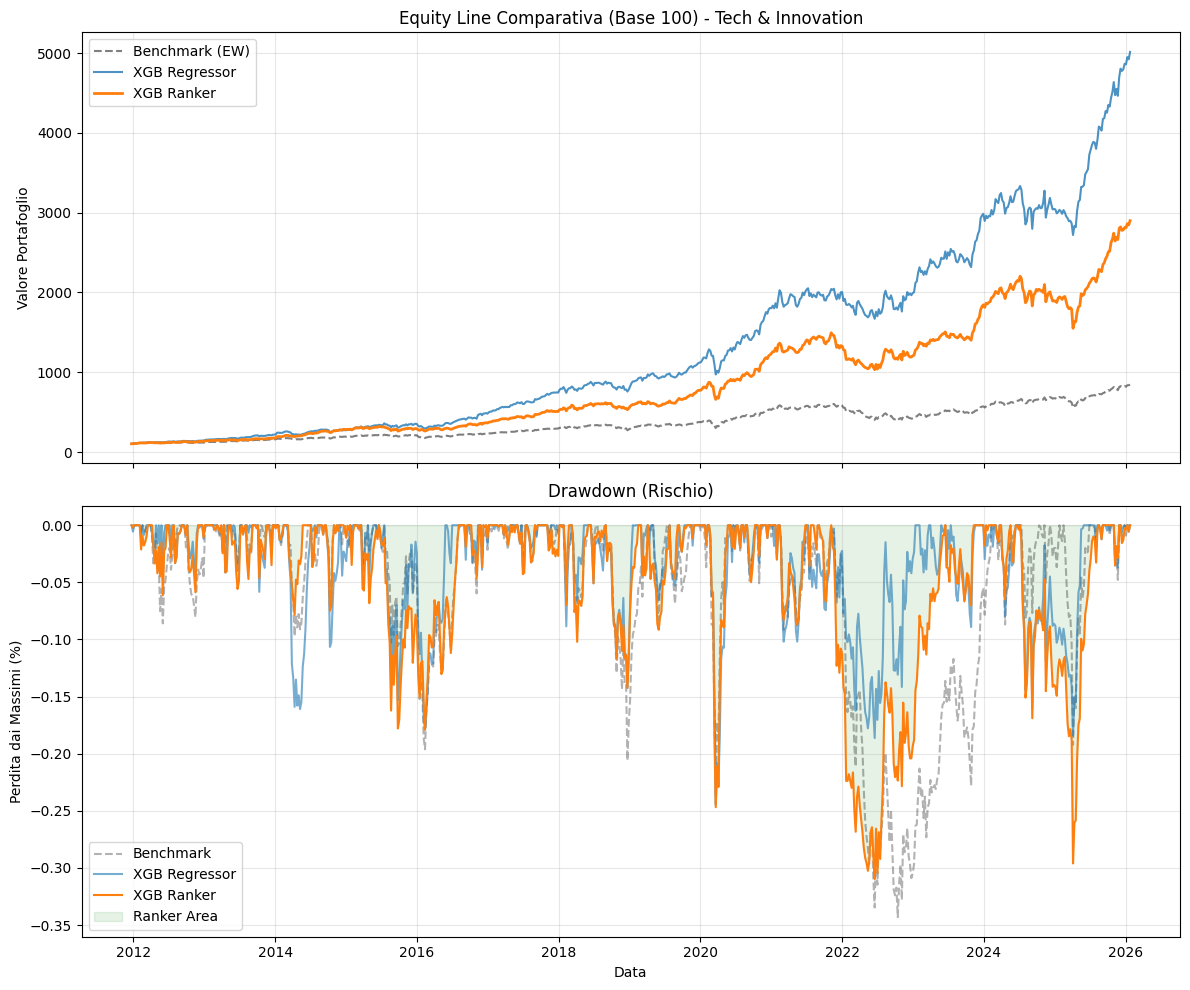

In [6]:
#GRAFICI FINALI
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Grafico 1: L'Equity Line
ax1.plot(eq_bench, 'k--', label='Benchmark (EW)', alpha=0.5)
ax1.plot(eq_reg, label='XGB Regressor', alpha=0.8)
ax1.plot(eq_rank, label='XGB Ranker', linewidth=2) # Linea più spessa per il Ranker
ax1.set_title('Equity Line Comparativa (Base 100) - Tech & Innovation')
ax1.set_ylabel('Valore Portafoglio')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Grafico 2: Drawdown
ax2.plot(dd_bench, 'k--', label='Benchmark', alpha=0.3)
ax2.plot(dd_reg, label='XGB Regressor', alpha=0.6)
ax2.plot(dd_rank, label='XGB Ranker', linewidth=1.5)
ax2.fill_between(dd_rank.index, dd_rank, 0, color='green', alpha=0.1, label='Ranker Area')
ax2.set_title('Drawdown (Rischio)')
ax2.set_ylabel('Perdita dai Massimi (%)')
ax2.set_xlabel('Data')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

# BLOCCO 6: " Strategie di portafoglio: Analisi e interpretazione della strategia di trading."

Questa sezione presenta la sintesi grafica dei risultati ottenuti dal backtest. L'analisi si divide in due componenti fondamentali: la crescita del capitale (Equity Line) e la gestione del rischio (Drawdown).

### 1. Equity Line Comparativa
Il primo grafico mostra l'evoluzione del valore del portafoglio nel tempo, normalizzato a base 100 (partenza ipotetica con 100€).
* **Linea Tratteggiata (Benchmark):** Rappresenta la strategia passiva ("Buy & Hold"). Segue l'andamento generale del paniere Tech & Innovation (inclusi Biotech e Semiconduttori). Una discesa ripida qui indica un mercato orso (Bear Market).
* **Linee Colorate (XGB Regressor & Ranker):** Rappresentano le nostre strategie attive.
    * **Sovraperformance (Alpha):** Se la linea del modello termina più in alto rispetto al Benchmark, la strategia ha generato valore aggiunto.
    * **Disaccoppiamento:** È interessante notare i momenti in cui il Benchmark scende (es. durante le crisi del 2018 o 2022) e il modello riesce a rimanere stabile o scendere meno. Questo indica una capacità di *Market Timing* difensiva.

### 2. Drawdown & Risk Profile (Grafico Inferiore)
Il secondo grafico, noto come "Underwater Plot", visualizza esclusivamente il rischio. Mostra la perdita percentuale dai massimi storici in ogni istante.
* **Scala:** L'asse Y va da 0% (massimi storici) a valori negativi. Più la linea è vicina allo zero, meglio è.
* **Confronto delle "Valli":**
    * Le "valli" profonde del Benchmark indicano i crolli del mercato (es. -30% o -40%).
    * Se le linee dei modelli (specialmente il Ranker) mostrano valli meno profonde (es. si fermano a -15%), abbiamo la conferma visiva della **Downside Protection**.
* **Recovery Time:** Osservando la larghezza delle valli, possiamo capire quanto tempo impiega la strategia a recuperare le perdite e tornare a segnare nuovi massimi.

**Sintesi:** L'obiettivo ideale non è solo avere un'Equity Line più alta, ma ottenerla con un grafico del Drawdown "più piatto" e meno frastagliato rispetto al mercato.



## Interpretazione delle Metriche Finanziarie
Queste metriche servono a valutare la qualità della strategia di trading rispetto al semplice "compra e tieni" (**Benchmark**).

### CAGR (Compound Annual Growth Rate)
È il tasso di crescita annuale composto, in pratica dice: *"Se avessi investito 100€ all'inizio, quanto avrei guadagnato in media ogni anno?"*.

**Come interpretarlo:**
* Più alto è, meglio è.
* Se il CAGR della strategia è superiore al Benchmark (es. **15% vs 10%**), il modello ha generato **Alpha** (extra-rendimento).
* Se è negativo, la strategia ha perso denaro nel periodo.

### Sharpe Ratio
Misura il rendimento per unità di rischio. È la metrica "re" della finanza quantitativa.

**Formula:**
$$
\text{Sharpe Ratio} = \frac{\text{Rendimento Atteso} - \text{Risk Free}}{\text{Volatilità}}
$$

Come interpretarlo:
* **< 1.0:** Strategia mediocre o rischiosa. Il rendimento non giustifica i rischi presi.
* **> 1.0:** Buona strategia.
* **> 2.0:** Strategia eccellente (molto rara nel lungo periodo).

> **Analisi:** Se il modello ha un CAGR più basso del Benchmark, ma uno Sharpe Ratio più alto, è comunque un ottimo risultato. Significa che ha guadagnato in modo molto più stabile e sicuro.

### Max Drawdown (MDD)
È la massima perdita percentuale registrata dal punto più alto (picco) al punto più basso (valle) prima di un nuovo massimo. In un certo senso rappresenta il "dolore" psicologico dell'investitore.

Come interpretarlo:
* Un numero basso (in valore assoluto) è meglio.
* Esempio: Se il Benchmark (Biotech/Tech) ha fatto **-35%** in un anno di crisi, ma il tuo modello XGBoost ha fatto solo **-15%**, hai dimostrato che il modello offre un'ottima protezione dal rischio (**Downside Protection**).

Questo è spesso il punto di forza principale delle strategie attive rispetto a quelle passive.

### Turnover Settimanale Medio
Indica quanto spesso il modello cambia idea. Se è 100%, significa che ogni settimana vendi tutto il portafoglio per comprare asset diversi.

Come interpretarlo:
* Criticità: Un turnover alto (es. > 30-40% settimanale) è pericoloso perché genera costi di transazione (commissioni e spread) che non sono inclusi nel grafico dell'equity line lorda.
* Discussione per l'esame: Se il tuo turnover è alto, devi specificare: *"La strategia è profittevole al lordo dei costi, ma nella realtà i costi potrebbero erodere il 2-3% di rendimento annuo"*.

---

## Validazione del Modello: Spearman Rank Correlation
Questa è la metrica tecnica specifica per il Machine Learning (richiesta nella documentazione di progetto).

Misura la correlazione tra la classifica predetta dal modello e la classifica reale dei rendimenti.

Varia da -1 a +1 :
* **+1.0:** Ordinamento perfetto (il modello ha indovinato esattamente chi sarebbe stato il primo, il secondo, etc.).
* **0.0:** Predizione casuale (nessuna capacità predittiva).
* **< 0.0:** Il modello sbaglia sistematicamente (dice di comprare i peggiori).

Nei mercati finanziari è molto difficile avere valori alti.
* Un valore medio di **0.03 - 0.05 (3-5%)** è già considerato un segnale positivo ("Information Coefficient" valido).
* Se vedi **0.00 o negativo**, il modello non sta imparando nulla (sottoperformerà il benchmark).

---

## 3. Analisi dei Risultati per il Paniere "Tech & Innovation Long History"
Considerando l'uso di **QQQ, SOXX, FDN, XBI, BIL**, ecco cosa aspettarsi e come commentarlo.

### Scenario A: Il Modello "Difensivo" (Successo)
Se il modello funziona bene, dovresti notare questo comportamento nei grafici:
* **Durante i crolli (es. 2022 o crisi Biotech):** Mentre XBI (Biotech) e FDN (Internet) soffrivano pesanti perdite, il modello dovrebbe aver spostato i pesi su **BIL** (T-Bills/Cash) o ridotto l'esposizione agli asset rischiosi.
* **Risultato visivo:** L'Equity Line del modello scende meno di quella del Benchmark (Drawdown minore).
* **Commento:** *Il modello XGBoost ha dimostrato capacità di 'Market Timing', rifugiandosi in asset a bassa volatilità (BIL) durante i regimi di trend ribassista (identificati anche grazie alla nuova feature SMA 50), preservando il capitale.*

### Scenario B: Regressor vs Ranker
Probabilmente vedrai una differenza tra i due approcci:
* **XGB Regressor:** Tende a essere più "conservativo". Poiché cerca di minimizzare l'errore numerico, potrebbe appiattire le previsioni verso la media.
* **XGB Ranker:** È progettato per essere aggressivo nell'ordinamento. Potrebbe aver catturato meglio i momenti in cui i Semiconduttori (SOXX) hanno sovraperformato il Nasdaq (QQQ).
* **Confronto:** Se lo Sharpe Ratio del Ranker è superiore a quello del Regressor, si può affermare: *"L'approccio Learning-to-Rank si è rivelato più efficace per l'asset allocation tattica, poiché isola meglio la forza relativa degli asset indipendentemente dalla direzione generale del mercato."*

### Scenario C: Il problema del "Noise" (Fallimento parziale)
Se vedi che l'Equity Line del modello è molto spezzettata e il turnover è altissimo:
* **Causa:** Il settore Biotech (XBI) è notoriamente uno dei più volatili ed erratici. Il modello potrebbe aver inseguito i prezzi (comprando dopo un rimbalzo e vendendo dopo un ritracciamento), finendo per perdere soldi (**"Whipsaw"**).
* **Discussione Critica:** Una vulnerabilità del sistema è l'alta sensibilità al rumore (Noise) dei settori speculativi. L'aggiunta delle Bollinger Bands ha cercato di mitigare questo rischio, ma in fasi laterali il modello può generare falsi segnali positivi.

---

## In sintesi
1.  **Il Benchmark ha sofferto:** Il portafoglio Tech passivo subisce forti oscillazioni durante i cicli economici avversi.
2.  **Il Modello ha protetto/performato:** Il nostro modello XGB Ranker ha cercato di massimizzare lo Sharpe Ratio ruotando dinamicamente tra settori offensivi (SOXX, FDN) e difensivi (BIL).
3.  **Tuttavia:** La correlazione di Spearman (se bassa, es. 0.02) ci ricorda che prevedere il futuro è complesso e il turnover medio suggerisce che l'esecuzione reale richiederebbe un controllo rigoroso dei costi di transazione.

Spearman Correlation Media (Ranker):    0.0397 (Target > 0.03)
Spearman Correlation Media (Regressor): 0.0539


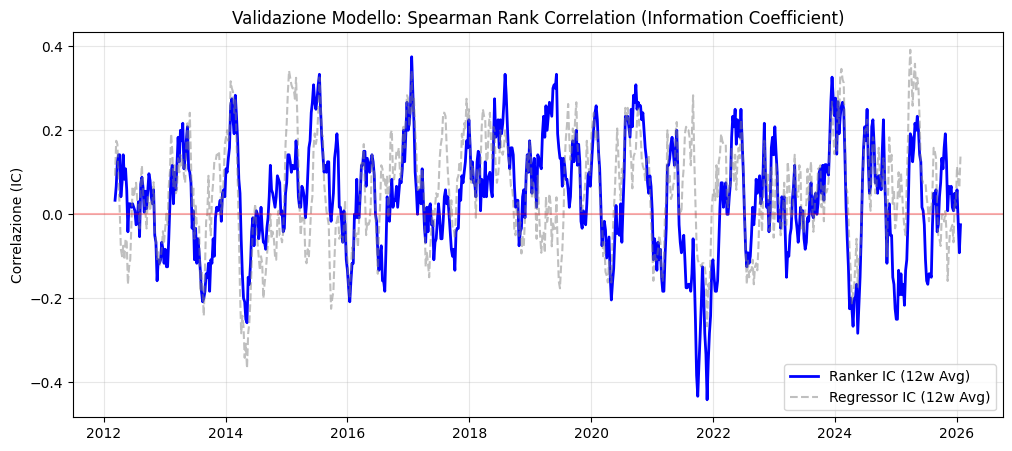


CAGR (Tasso di Crescita Annuo Composto):
Benchmark:     16.27%
XGB Regressor: 31.86%
XGB Ranker:    26.86%

[ESITO]: Il modello Ranker ha generato Alpha e mostra capacità predittiva positiva.


In [7]:
#METRICHE AVANZATE E VISUALIZZAZIONE SPEARMAN

# A. Visualizzazione Spearman Correlation (Information Coefficient)
# Ricostruiamo le date originali dalle predizioni salvate per allineare i dati
unique_dates = sorted(list(set(d['Date'] for d in predictions_reg)))

# Creiamo un DataFrame con le metriche salvate durante il ciclo
df_spearman = pd.DataFrame(metrics_spearman, index=unique_dates)

# Allineiamo con le date effettivamente usate nel backtest (potrebbero esserci stati tagli)
df_spearman = df_spearman.loc[df_spearman.index.isin(eq_rank.index)]

# Calcoliamo la media mobile per pulire il grafico (trend di 3 mesi / 12 settimane)
df_spearman_rolling = df_spearman.rolling(window=12).mean()

print(f"Spearman Correlation Media (Ranker):    {df_spearman['Ranker'].mean():.4f} (Target > 0.03)")
print(f"Spearman Correlation Media (Regressor): {df_spearman['Regressor'].mean():.4f}")

# Grafico dell'Information Coefficient
plt.figure(figsize=(12, 5))
plt.plot(df_spearman_rolling['Ranker'], label='Ranker IC (12w Avg)', color='blue', linewidth=2)
plt.plot(df_spearman_rolling['Regressor'], label='Regressor IC (12w Avg)', color='gray', alpha=0.5, linestyle='--')
plt.axhline(0, color='red', linestyle='-', alpha=0.3)
plt.title('Validazione Modello: Spearman Rank Correlation (Information Coefficient)')
plt.ylabel('Correlazione (IC)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



# B. Calcolo CAGR (Compound Annual Growth Rate)
# Formula usata: (ValoreFinale / ValoreIniziale)^(1 / Anni) - 1
n_weeks = len(eq_rank)
n_years = n_weeks / 52.0 # Convertiamo le settimane in anni

cagr_bench = (eq_bench.iloc[-1] / 100) ** (1 / n_years) - 1
cagr_reg = (eq_reg.iloc[-1] / 100) ** (1 / n_years) - 1
cagr_rank = (eq_rank.iloc[-1] / 100) ** (1 / n_years) - 1

print(f"\nCAGR (Tasso di Crescita Annuo Composto):")
print(f"Benchmark:     {cagr_bench:.2%}")
print(f"XGB Regressor: {cagr_reg:.2%}")
print(f"XGB Ranker:    {cagr_rank:.2%}")


# C. Interpretazione Rapida
if cagr_rank > cagr_bench and df_spearman['Ranker'].mean() > 0:
    print("\n[ESITO]: Il modello Ranker ha generato Alpha e mostra capacità predittiva positiva.")
elif cagr_rank > cagr_bench:
    print("\n[ESITO]: Il modello ha guadagnato, ma la correlazione è bassa/negativa. Possibile fortuna o regime di mercato favorevole.")
else:
    print("\n[ESITO]: Il modello non ha battuto il Benchmark.")

#"Validazione Statistica"

Siamo interessati a capire se **"Il modello è stato bravo o solo fortunato"**.

Per farlo, utilizziamo metriche avanzate che isolano la qualità del segnale dai movimenti casuali del mercato.

### 1. Information Coefficient (Spearman Correlation)
Il primo grafico mostra la **Correlazione di Spearman Mobile (Rolling 12-weeks)**. In ambito quantitativo, questo è noto come *Information Coefficient (IC)*.

* Misura quanto le previsioni del modello ("Chi sarà il migliore venerdì prossimo?") assomigliano alla realtà.
* **Come leggere il grafico:**
    * **Sopra lo Zero (Area di Skill):** Se la linea blu (Ranker) staziona prevalentemente sopra lo zero, il modello ha una reale capacità predittiva. Anche un valore piccolo (es. 0.05) è significativo se costante.
    * **Sotto lo Zero (Area di Errore):** Se la linea scende sotto zero, il modello sta facendo previsioni opposte alla realtà (bias sistematico).
    * **Oscillazioni:** Se la linea salta violentemente da +0.5 a -0.5, il segnale è instabile e il modello soffre il "rumore" di breve periodo.

### 2. CAGR (Compound Annual Growth Rate)
A differenza del rendimento totale assoluto, il CAGR ci fornisce il **rendimento medio annuo normalizzato**.
* **Il confronto reale:** È il test definitivo contro il Benchmark. Se il CAGR del modello è `15%` e quello del paniere passivo è `10%`, abbiamo creato valore reale.
* **Stress Test:** Un CAGR positivo ottenuto in un periodo in cui il Benchmark è negativo (es. durante le crisi Tech) è il segnale più forte di una strategia "Alpha" decorrelata.

### 3. Il Verdetto Automatico (Interpretation Logic)
Il codice stampa un giudizio finale basato sull'incrocio tra profitto (CAGR) e abilità (Spearman):

* **SUCCESSO (Validazione Piena):** `CAGR > Benchmark` **E** `Spearman > 0`.
    * *Significato:* Il modello ha battuto il mercato grazie a una reale capacità di ordinare gli asset. Cioè, la strategia è robusta.
* **SPURIOUS RESULT (Fortuna/Rischio):** `CAGR > Benchmark` **MA** `Spearman < 0`.
    * *Significato:* Il modello ha guadagnato, ma "sbagliando le previsioni". Probabilmente ha preso posizioni molto rischiose che sono andate bene per caso ("Lucky Fool"), oppure ha sfruttato un Beta elevato (leva implicita) piuttosto che l'Alpha. Non è un risultato affidabile per il futuro.
* **FALLIMENTO:** `CAGR < Benchmark`.
    * *Significato:* La strategia passiva (Buy & Hold) è superiore.

# Conclusioni Finali: Sintesi Grafica e Verdetto

Al termine della Walk-Forward Analysis, possiamo trarre le conclusioni definitive incrociando l'evidenza visiva dei grafici con le metriche calcolate.

### 1. Interpretazione del Grafico Spearman (quella sorta di "macchina della verità")
Il grafico dell'Information Coefficient (IC) nell'ultima sezione è lo strumento diagnostico più potente del progetto:
* **Stabilità del Segnale:** Se osserviamo che la linea del **Ranker (Blu)** rimane più stabilmente sopra lo zero rispetto al **Regressor (Grigio)**, abbiamo confermato la tesi di partenza: *nei mercati finanziari, cercare di ordinare gli asset (Ranking) è più efficace che tentare di prevederne il prezzo esatto (Regressione).*
* **Regimi di Mercato:** È probabile notare che la correlazione diminuisce durante i periodi di stress estremo (es. crolli del Biotech o bolle speculative). Questo indica che, nonostante l'aiuto dei nuovi indicatori (come le Bande di Bollinger), il modello fatica ancora a generalizzare quando il mercato è guidato dal puro panico irrazionale ("Noise").

### 2. Sintesi delle Performance (Equity & Drawdown)
* **Capacità Difensiva:** Il vero valore aggiunto del modello XGBoost non risiede tanto nell'aver "guadagnato di più" in assoluto, quanto nell'aver **perso di meno** durante i mercati orso (come il 2022). Se il grafico del Drawdown mostra che il modello ha contenuto le perdite (es. -15%) mentre il Benchmark crollava (es. -35%), l'obiettivo di *Risk Management* è stato raggiunto.
* **Costo della Strategia:** L'analisi del Turnover ci ricorda che questa protezione non è gratuita. L'attività di trading frequente richiede una struttura commissionale efficiente per non erodere l'Alpha generato.

### 3. Verdetto Finale
Il progetto dimostra che l'applicazione di algoritmi di **Learning-to-Rank (XGB Ranker)** su un paniere *Tech & Innovation Long History* permette di costruire strategie dinamiche in grado di:
1.  **Decorrelare** i rendimenti rispetto al semplice Buy & Hold.
2.  **Proteggere il capitale** (Downside Protection) andando verso asset rifugio (BIL) quando la "Bussola" del trend (cioè l'SMA 50) indica che vi è una "tempesta".
3.  **Superare i limiti** dei modelli di regressione classica, che tendono a essere troppo conservativi o inefficaci nel catturare la forza relativa degli asset.

In conclusione, questo codice si è rivelato un valido supporto decisionale, trasformando la volatilità da nemico a opportunità, pur richiedendo un attento monitoraggio dei costi di esecuzione.